In [3]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Reshape
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import itertools
from PIL import Image

In [ ]:
# !conda install -c conda-forge cudatoolkit=11.8 cudnn=8.6
!pip install matplotlib scikit-learn
# !conda install -c conda-forge cudnn=8.4.1.50




In [2]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Available GPUs:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.10.1
Built with CUDA: True
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Set the base path
base_path = r'C:/Users/jesli/Downloads/sorted_images'

# # Organize data into train, valid, test directories
# os.chdir(base_path)
# if not os.path.isdir('train/class_0'):
#     os.mkdir('train')
#     os.mkdir('valid')
#     os.mkdir('test')

#     for i in range(14):  # Adjusted for classes 0 to 13
#         shutil.move(f'class_{i}', 'train')
#         os.mkdir(f'valid/class_{i}')
#         os.mkdir(f'test/class_{i}')

#         valid_samples = random.sample(os.listdir(f'train/class_{i}'), 30)
#         for j in valid_samples:
#             shutil.move(f'train/class_{i}/{j}', f'valid/class_{i}')

#         test_samples = random.sample(os.listdir(f'train/class_{i}'), 5)
#         for k in test_samples:
#             shutil.move(f'train/class_{i}/{k}', f'test/class_{i}')
# os.chdir('../..')


In [5]:
# Paths
train_path = os.path.join(base_path, 'train')
valid_path = os.path.join(base_path, 'valid')
test_path = os.path.join(base_path, 'test')


In [6]:
# Data Generators
train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow_from_directory(
    directory=train_path, target_size=(224,224), batch_size=10)
valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow_from_directory(
    directory=valid_path, target_size=(224,224), batch_size=10)
test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow_from_directory(
    directory=test_path, target_size=(224,224), batch_size=10, shuffle=False)


Found 7927 images belonging to 14 classes.
Found 420 images belonging to 14 classes.
Found 70 images belonging to 14 classes.


In [7]:
# Build the model
mobile = tf.keras.applications.mobilenet.MobileNet()
x = mobile.layers[-5].output
x = Reshape(target_shape=(1024,))(x)
output = Dense(units=14, activation='softmax')(x)


In [8]:
model = Model(inputs=mobile.input, outputs=output)

# Freeze layers
for layer in model.layers[:-22]:
    layer.trainable = False


In [9]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [13]:
# Train the model
model.fit(
    x=train_batches,
    steps_per_epoch=len(train_batches),
    validation_data=valid_batches,
    validation_steps=len(valid_batches),
    epochs=200,
    verbose=2
)


Epoch 1/200
793/793 - 21s - loss: 0.0529 - accuracy: 0.9868 - val_loss: 2.4227 - val_accuracy: 0.6048 - 21s/epoch - 27ms/step
Epoch 2/200
793/793 - 20s - loss: 0.0553 - accuracy: 0.9861 - val_loss: 2.1813 - val_accuracy: 0.6024 - 20s/epoch - 26ms/step
Epoch 3/200
793/793 - 20s - loss: 0.0498 - accuracy: 0.9866 - val_loss: 2.4266 - val_accuracy: 0.5952 - 20s/epoch - 26ms/step
Epoch 4/200
793/793 - 21s - loss: 0.0469 - accuracy: 0.9878 - val_loss: 2.2424 - val_accuracy: 0.6286 - 21s/epoch - 26ms/step
Epoch 5/200
793/793 - 21s - loss: 0.0427 - accuracy: 0.9893 - val_loss: 2.8453 - val_accuracy: 0.6024 - 21s/epoch - 27ms/step
Epoch 6/200
793/793 - 21s - loss: 0.0462 - accuracy: 0.9894 - val_loss: 2.2566 - val_accuracy: 0.6238 - 21s/epoch - 27ms/step
Epoch 7/200
793/793 - 21s - loss: 0.0451 - accuracy: 0.9880 - val_loss: 2.4667 - val_accuracy: 0.6071 - 21s/epoch - 26ms/step
Epoch 8/200
793/793 - 20s - loss: 0.0332 - accuracy: 0.9921 - val_loss: 2.5082 - val_accuracy: 0.6167 - 20s/epoch - 26

In [14]:

# Evaluate the model
test_labels = test_batches.classes
predictions = model.predict(x=test_batches, steps=len(test_batches), verbose=0)


Confusion matrix, without normalization
[[4 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 3 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 1 0 0 0 0 1 0]
 [0 0 0 4 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 5 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 4 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 2 1 0 0 0 1 0 0]
 [1 0 1 1 0 0 0 2 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 5 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 5 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 3 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 2 2 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 4]]


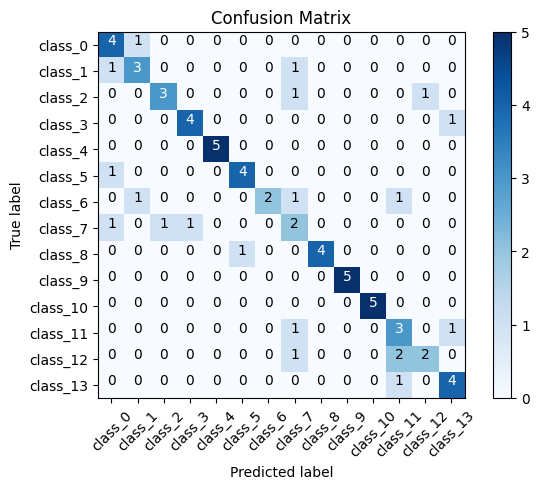

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_true=test_labels, y_pred=predictions.argmax(axis=1))

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

cm_plot_labels = [f'class_{i}' for i in range(14)]
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix')
plt.show()